# TikTok Claims Classification: Part 1 - EDA & Data Synthesis

This project seeks to develop a machine learning model to assist in the classification of claims for user submissions. In this part of the project, the data needs to be analyzed, explored, cleaned, and structured prior to any model building.

### **Import packages**

In [1]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook')

### **Exploring and Cleaning data**

Importing dataset.

In [2]:
data = pd.read_csv("data/tiktok_dataset.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


After first inspection, there are some columns with missing values.

In [3]:
# Check for missing values
data.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

There are few rows with null values, they can be dropped.

In [4]:
# Drop rows with missing values
data = data.dropna(axis=0).reset_index(drop=True)

Check for duplicated rows.

In [5]:
# Check for duplicates
data.duplicated().sum()

np.int64(0)

There are no duplicate observations in the data.



Checking data distribution.

In [6]:
# Get summary statistics
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19084.000000,1.908400e+04,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9542.500000,5.624840e+09,32.423811,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5509.220604,2.537030e+09,16.226470,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4771.750000,3.425100e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9542.500000,5.609500e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14313.250000,7.840823e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19084.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


There are very high values for the counts (views, likes, comments, shares and downloads) compared to the lower quartiles.

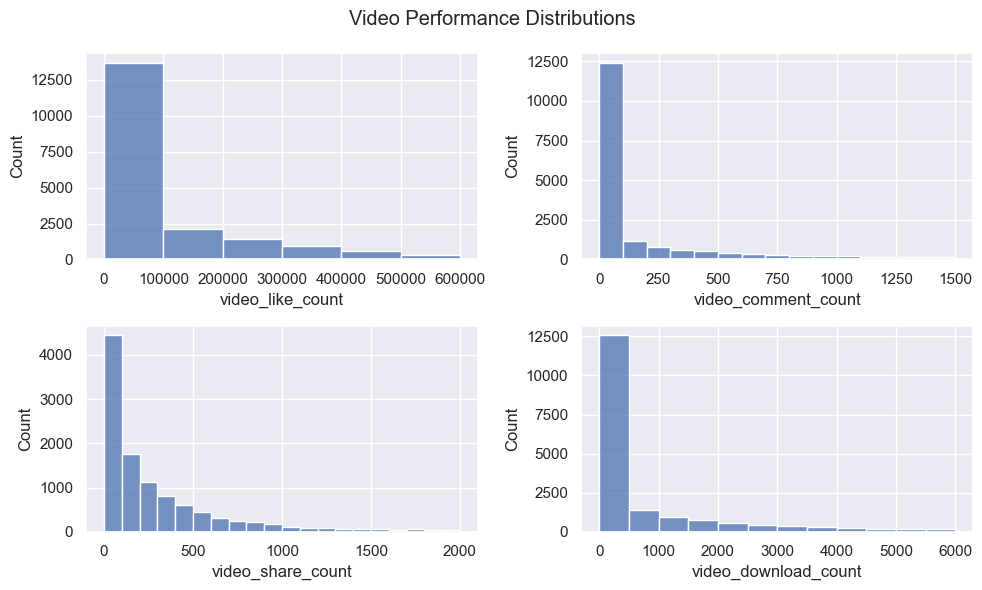

In [7]:
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(10,6)
fig.suptitle('Video Performance Distributions')
sns.histplot(data['video_like_count'], bins=range(0,(6*10**5+1),10**5), ax=ax[0,0])
sns.histplot(data['video_comment_count'], bins=range(0,(1501),100), ax=ax[0,1])
sns.histplot(data['video_share_count'], bins=range(0,(2001),100), ax=ax[1,0])
sns.histplot(data['video_download_count'], bins=range(0,(6001),500), ax=ax[1,1])
plt.tight_layout()
plt.show()

All the engagement metrics shows a distribution heavily right-skewed. This means that very few videos gets very high engagement metrics. This aligns with expectation of how social media works. That's the nature of viral content.

#### **Outliers**
The objective of this project is to build a model that predicts if a video is a Claim or an Opinion. The video engagement is potentially a good indicator of claim status and emoving the outliers could bring problems when building the model, given the right-skewed distribution of the data.

For this reason the outliers are going to be kept for building the model.

### **Export cleaned dataset**

In [8]:
data.to_csv('./data/tiktok_dataset_cleaned.csv', index=False)

### **Analysis**

After first inspection and cleaning of the data, the starting point is to review the amount of claims and opinions in the dataset.

In [8]:
data['claim_status'].value_counts()

claim_status
claim      9608
opinion    9476
Name: count, dtype: int64

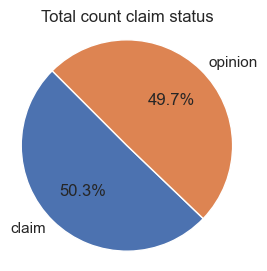

In [9]:
fig = plt.figure(figsize=(3,3))
plt.pie(data['claim_status'].value_counts(), labels=['claim','opinion'], autopct='%1.1f%%', startangle=135)
plt.axis('equal')
plt.title('Total count claim status');

The counts of each value are balanced. there are not underrepresentation.

#### **Claim status by author ban status**

In [10]:
# Get counts for each group combination of claim status and author ban status
data.groupby(['author_ban_status', 'claim_status']).count()[['#']].reset_index()

,author_ban_status,claim_status,#
0,active,claim,6566
1,active,opinion,8817
2,banned,claim,1439
3,banned,opinion,196
4,under review,claim,1603
5,under review,opinion,463


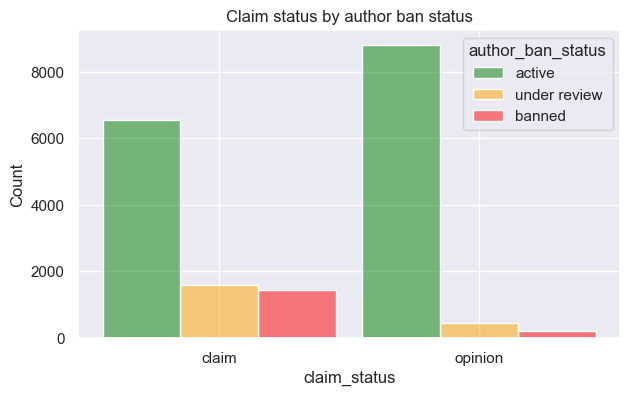

In [11]:
fig = plt.figure(figsize=(7,4))
sns.histplot(data, x='claim_status', hue='author_ban_status',
             multiple='dodge',
             hue_order=['active', 'under review', 'banned'],
             shrink=0.9,
             palette={'active':'green', 'under review':'orange', 'banned':'red'},
             alpha=0.5)
plt.title('Claim status by author ban status');

For both types of claim status, claim and opinion videos, there are much more active authors than banned or under review authors (non-active authors). 
Banned authors represent the 15% of all videos with 'claim' status, while only 2% of videos with 'opinion' status. This possibly means that "claim" videos get more reviewed than "opinion" videos.

#### **Median view counts by ban status**

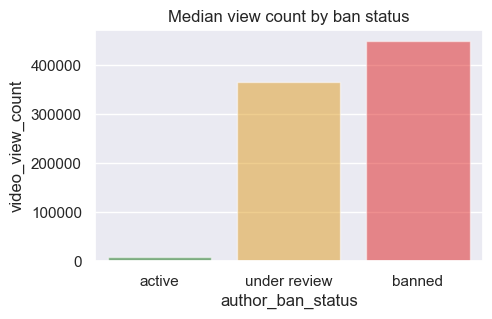

In [12]:
ban_status_counts = data.groupby(['author_ban_status']).median(
    numeric_only=True).reset_index()

fig = plt.figure(figsize=(5,3))
sns.barplot(data=ban_status_counts,
            x='author_ban_status',
            y='video_view_count',
            order=['active', 'under review', 'banned'],
            palette={'active':'green', 'under review':'orange', 'banned':'red'},
            hue='author_ban_status',
            alpha=0.5)
plt.title('Median view count by ban status');

Videos by Non-active authors have much more views than the active authors. video view count is a good predictor of claim status since videos by non-active authors are more likely to be claims and get more views.

Checking the median of video view count by claim status will ensure this asessment.

In [72]:
data.groupby(['claim_status'])[['video_view_count']].agg(['mean','median'])

video_view_count          
                         mean    median
claim_status                           
claim           501029.452748  501555.0
opinion           4956.432250    4953.0

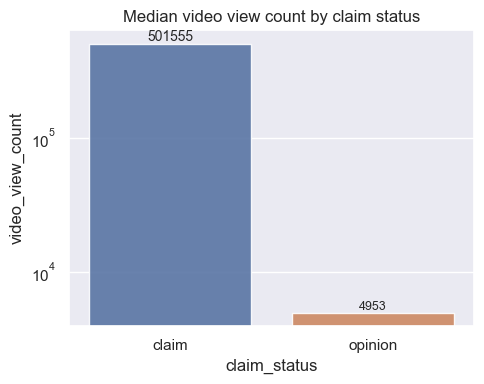

In [74]:
fig = plt.figure(figsize=(5,4))
ax = sns.barplot(data,
                 x='claim_status',
                 y='video_view_count',
                 estimator='median',
                 hue='claim_status',
                 errorbar=None,
                 alpha=0.9)
plt.title('Median video view count by claim status');
plt.yscale('log')
plt.tight_layout()
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=9);

For both, claim and opinion videos, the view count mean and the median are too close. The video view count is clearly bigger for the videos with 'claim' status, even though the count of videos has an equivalent distribution of nearly 50%.

#### **Engagement metrics: views, likes and shares counts**

Knowing that non-active authors get more view counts, the next step is to explore more in detail the engagement metrics, additional to the view count.

In [14]:
data.groupby('author_ban_status')[['video_view_count', 'video_like_count', 'video_share_count']].agg(['mean','median']).round(2)

video_view_count           video_like_count            \
                              mean    median             mean    median   
author_ban_status                                                         
active                   215927.04    8616.0         71036.53    2222.0   
banned                   445845.44  448201.0        153017.24  105573.0   
under review             392204.84  365245.5        128718.05   71204.5   

                  video_share_count           
                               mean   median  
author_ban_status                             
active                     14111.47    437.0  
banned                     29998.94  14468.0  
under review               25774.70   9444.0

* Videos by banned and under review authors have more views, likes and shares in average than active users.
* The amount of videos by banned authors shared is significantly higher than the videos by active users.
* The media and the mean are too sepparated in the likes and shares for all types of author. This indicates a very high engagement of some of these videos

To understand better the engament, three new columns are added to represent rates per view: `likes_per_view`, `comments_per_view`, `shares_per_view`

In [15]:
# Create new columns
data['likes_per_view'] = data.video_like_count/data.video_view_count
data['comments_per_view'] = data.video_comment_count/data.video_view_count
data['shares_per_view'] = data.video_share_count/data.video_view_count

data.groupby(['claim_status', 'author_ban_status'])[['likes_per_view','comments_per_view','shares_per_view']].agg(['mean','median'])


likes_per_view           comments_per_view  \
                                         mean    median              mean   
claim_status author_ban_status                                              
claim        active                  0.329542  0.326538          0.001393   
             banned                  0.345071  0.358909          0.001377   
             under review            0.327997  0.320867          0.001367   
opinion      active                  0.219744  0.218330          0.000517   
             banned                  0.206868  0.198483          0.000434   
             under review            0.226394  0.228051          0.000536   

                                         shares_per_view            
                                  median            mean    median  
claim_status author_ban_status                                      
claim        active             0.000776        0.065456  0.049279  
             banned             0.000746        0.067893  0.051606  
             under review       0.000789        0.065733  0.049967  
opinion      active             0.000252        0.043729  0.032405  
             banned             0.000193        0.040531  0.030728  
             under review       0.000293        0.044472  0.035027

- The engagement per view is more related to the `claim_status` than the `author_ban_status`. Claim videos get more likes, comments and shares per view than opinion videos.
- Banned authors still get more likes and shares per view when the video is flagged as claim. However, when the video is flagged as an opinion, banned authors get less engagement per view.

In [24]:

test = data.groupby(['claim_status'])[['video_view_count','likes_per_view','comments_per_view','shares_per_view']].median()
test

,video_view_count,likes_per_view,comments_per_view,shares_per_view
claim_status,,,,
claim,501555.0,0.329734,0.000774,0.049673
opinion,4953.0,0.218127,0.000253,0.032487


### **Conclusion**


#### Insights
- 9,608 of the videos are claims, this represents 50.3% of the videos in the data set. The other 49.7% are opinion videos. The data is well balanced as it represent the claim status fairly.
- Claim status is high correlated with engagement levels, making them good predictor for the model.
- Claim videos by Banned authors have a higher engagement level than Active authors.
